## Step 0: Load Cleaned Data

Loading the preprocessed dataset saved at the end of Stage 1, so this
notebook can run independently without repeating the cleaning steps.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/diabetic_data_cleaned.csv")
print("Shape:", df.shape)
df.head()

Shape: (96436, 48)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30d
0,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,Up,No,No,No,No,No,Ch,Yes,>30,0
1,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,No,Yes,NO,0
2,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,Up,No,No,No,No,No,Ch,Yes,NO,0
3,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,Steady,No,No,No,No,No,Ch,Yes,NO,0
4,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,Unknown,...,Steady,No,No,No,No,No,No,Yes,>30,0


## Step 1: Readmission Rate by Medical Specialty

This is the key exploratory plot for the whole project — it shows readmission
rate per specialty alongside each specialty's sample size. The pattern we
expect to see (small specialties with wildly noisy rates, large specialties
with stable rates) is the direct visual justification for using a hierarchical
model with partial pooling instead of fitting each specialty separately.

                                   readmit_rate  n_encounters
medical_specialty                                            
Unknown                                0.118743         47523
InternalMedicine                       0.116136         13665
Emergency/Trauma                       0.113633          7357
Family/GeneralPractice                 0.122216          7004
Cardiology                             0.081542          5163
Surgery-General                        0.112283          2939
Nephrology                             0.162037          1512
Orthopedics                            0.111193          1349
Orthopedics-Reconstructive             0.074913          1148
Radiologist                            0.089674          1104
Psychiatry                             0.123171           820
Pulmonology                            0.112607           817
Urology                                0.105512           635
ObstetricsandGynecology                0.045886           632
Surgery-

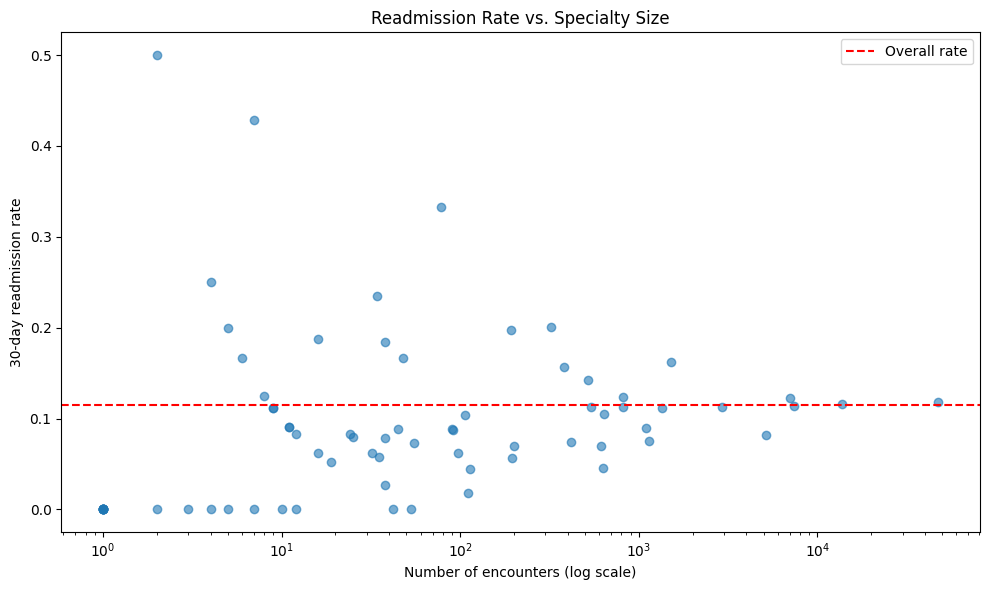

In [3]:
import matplotlib.pyplot as plt

# Readmission rate and count per specialty
specialty_stats = df.groupby('medical_specialty')['readmitted_30d'].agg(['mean', 'count']).sort_values('count', ascending=False)
specialty_stats.columns = ['readmit_rate', 'n_encounters']

print(specialty_stats.head(20))

# Plot: readmission rate vs. sample size per specialty
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(specialty_stats['n_encounters'], specialty_stats['readmit_rate'], alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel('Number of encounters (log scale)')
ax.set_ylabel('30-day readmission rate')
ax.set_title('Readmission Rate vs. Specialty Size')
ax.axhline(df['readmitted_30d'].mean(), color='red', linestyle='--', label='Overall rate')
ax.legend()
plt.tight_layout()
plt.savefig('../slides/readmit_rate_by_specialty.png', dpi=150)
plt.show()

## Interpretation: Readmission Rate vs. Specialty Size

This plot is exactly the pattern that justifies the whole modeling choice.

- **The funnel shape is textbook.** On the left side (small specialties,
  n < 20), readmission rates swing wildly — from 0% up to 50%. Several
  specialties with n=1 or n=2 sit at either 0.0 or 0.5, which isn't a real
  difference in risk, it's just noise from having almost no data. On the
  right side (large specialties, n > 1,000), rates settle into a tight band
  roughly between 7% and 16%, hugging the red overall-rate line closely.
- **This is precisely the problem partial pooling solves.** A no-pooling
  model would take that specialty with n=2 and 50% readmission at face
  value — treating it as a genuinely high-risk specialty — when it's almost
  certainly just two unlucky patients. A hierarchical model will pull that
  estimate strongly toward the overall average (heavy shrinkage for small
  n), while barely touching `InternalMedicine` or `Family/GeneralPractice`
  (large n, estimates already stable). This plot is worth including directly
  in your slides — it's the clearest possible visual argument for why this
  model is the right one for this data.
- **One genuine signal worth flagging:** `Oncology` (n=323) sits notably
  above the line at 20.1%, and `Nephrology` (n=1,512) at 16.2% — both have
  enough volume that this isn't just noise, and both are clinically
  plausible (cancer and kidney disease patients are known higher-readmission
  populations). These are worth watching once the hierarchical model gives
  you proper uncertainty intervals — if the credible interval for Oncology
  stays clearly above the overall rate even after shrinkage, that's a real
  finding for your interpretation section.
- **`Unknown` (n=47,523, our largest group) sits almost exactly on the
  overall average (11.9%)** — reassuring, since it suggests missing
  specialty isn't strongly associated with different readmission risk, so
  our earlier decision to keep it as its own category rather than drop it
  looks like the right call in hindsight.

## Step 2: Distribution of Candidate Predictors

Before modeling, we look at the distributions of the other candidate
predictors — age, time in hospital, number of diagnoses, and number of
medications — both overall and split by readmission status. This tells us
which variables show a visible relationship with readmission and flags any
skew or outliers we should be aware of before fitting.

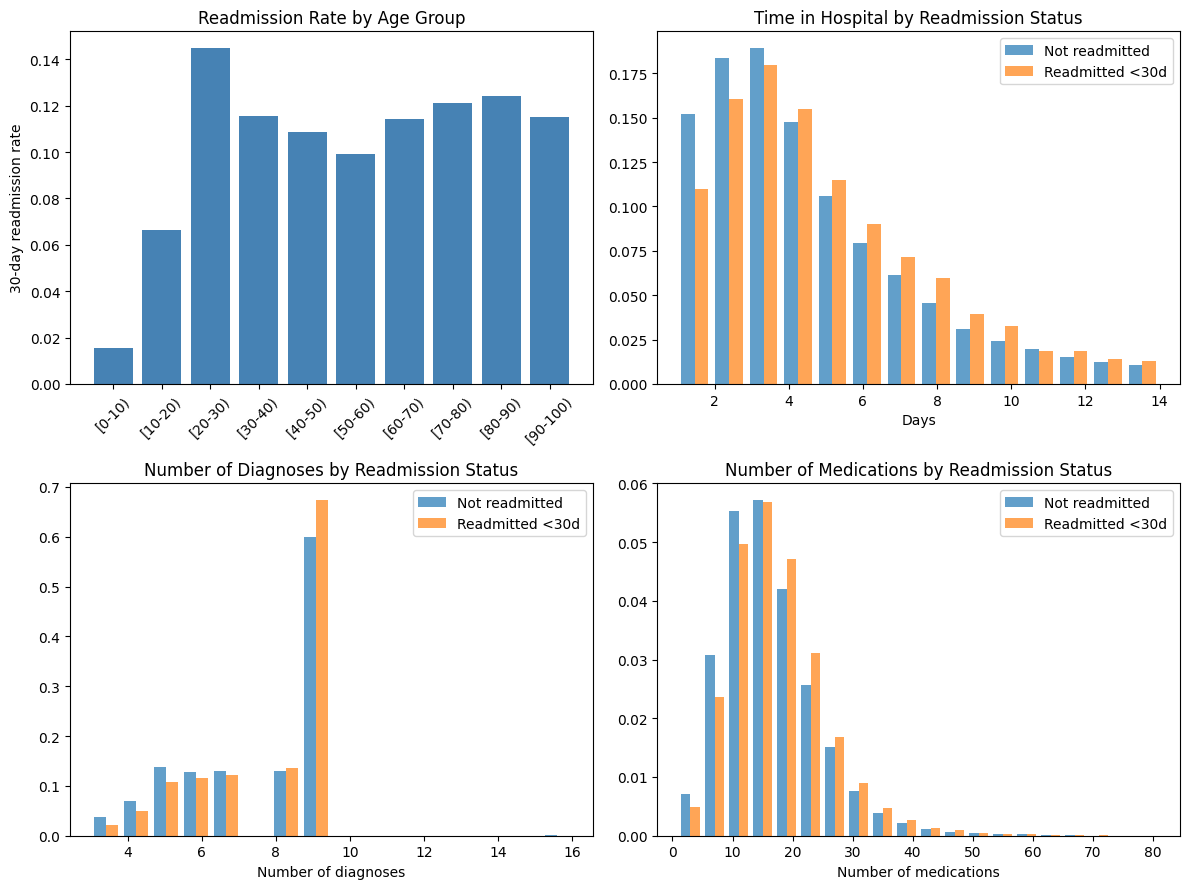


time_in_hospital:
                    mean       std  50%
readmitted_30d                         
0               4.367635  2.971966  4.0
1               4.786192  3.035713  4.0

number_diagnoses:
                    mean       std  50%
readmitted_30d                         
0               7.467389  1.851058  8.0
1               7.750949  1.701269  9.0

num_medications:
                     mean       std   50%
readmitted_30d                           
0               15.964144  8.061001  15.0
1               16.978312  8.104764  16.0


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Age (ordered categorical)
age_order = sorted(df['age'].unique(), key=lambda x: int(x.split('-')[0][1:]))
age_readmit = df.groupby('age')['readmitted_30d'].mean().reindex(age_order)
axes[0, 0].bar(age_readmit.index, age_readmit.values, color='steelblue')
axes[0, 0].set_title('Readmission Rate by Age Group')
axes[0, 0].set_ylabel('30-day readmission rate')
axes[0, 0].tick_params(axis='x', rotation=45)

# Time in hospital
axes[0, 1].hist([df[df['readmitted_30d']==0]['time_in_hospital'],
                  df[df['readmitted_30d']==1]['time_in_hospital']],
                 bins=14, label=['Not readmitted', 'Readmitted <30d'],
                 density=True, alpha=0.7)
axes[0, 1].set_title('Time in Hospital by Readmission Status')
axes[0, 1].set_xlabel('Days')
axes[0, 1].legend()

# Number of diagnoses
axes[1, 0].hist([df[df['readmitted_30d']==0]['number_diagnoses'],
                  df[df['readmitted_30d']==1]['number_diagnoses']],
                 bins=16, label=['Not readmitted', 'Readmitted <30d'],
                 density=True, alpha=0.7)
axes[1, 0].set_title('Number of Diagnoses by Readmission Status')
axes[1, 0].set_xlabel('Number of diagnoses')
axes[1, 0].legend()

# Number of medications
axes[1, 1].hist([df[df['readmitted_30d']==0]['num_medications'],
                  df[df['readmitted_30d']==1]['num_medications']],
                 bins=20, label=['Not readmitted', 'Readmitted <30d'],
                 density=True, alpha=0.7)
axes[1, 1].set_title('Number of Medications by Readmission Status')
axes[1, 1].set_xlabel('Number of medications')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../slides/predictor_distributions.png', dpi=150)
plt.show()

# Print summary stats split by readmission status
for col in ['time_in_hospital', 'number_diagnoses', 'num_medications']:
    print(f"\n{col}:")
    print(df.groupby('readmitted_30d')[col].describe()[['mean', 'std', '50%']])

In [5]:
print(df['age'].value_counts().reindex(age_order))

age
[0-10)         64
[10-20)       466
[20-30)      1471
[30-40)      3538
[40-50)      9208
[50-60)     16546
[60-70)     21518
[70-80)     24811
[80-90)     16221
[90-100)     2593
Name: count, dtype: int64


## Interpretation: Predictor Distributions

- **Age isn't monotonic in the way you'd expect.** Readmission rate is
  lowest for `[0-10)` (1.6%) and rises sharply through `[10-20)` and
  `[20-30)` — but `[20-30)` actually spikes to 14.5%, higher than every
  older age group, before settling into a fairly flat 10–12.5% band from
  `[30-40)` onward. This spike is not a small-sample artifact — `[20-30)`
  has 1,471 encounters, comfortably enough to treat the 14.5% rate as a
  real pattern rather than noise. If anything, the fragile group here is
  `[0-10)` at n=64, though its low rate is clinically plausible regardless.
  The `[20-30)` elevation is worth a one-line mention in the interpretation
  section — plausible explanations include a higher share of Type 1
  diabetes with less stable long-term management in this age band, or a
  demographic with more inconsistent follow-up care.

- **Time in hospital shows a real, if modest, relationship.** Readmitted
  patients have a slightly higher mean stay (4.79 vs. 4.37 days) — the
  histogram shows the orange (readmitted) bars sitting a bit higher than
  blue in the 4–10 day range and lower at the short end (1–2 days). Small
  but consistent effect, reasonable candidate predictor.

- **Number of diagnoses shows the clearest signal of the three continuous
  variables.** Both groups pile up heavily at 9 diagnoses (the apparent max
  in this data), but the *readmitted* group is disproportionately
  concentrated there (67% vs. 60% for non-readmitted) and correspondingly
  thinner in the low-diagnosis-count bins. Higher diagnosis count is one of
  the stronger differentiators here.

- **Number of medications shows a subtle but consistent shift.** The
  readmitted group's distribution is shifted slightly right (mean 16.98 vs.
  15.96), most visible in the 15–30 medication range where orange bars sit
  above blue. Weaker signal than diagnosis count, but still directionally
  useful.

**Bottom line:** none of these four are dramatically different between
groups on their own — which is expected and realistic for a readmission
problem — but `number_diagnoses` and `age` (including the genuine `[20-30)`
elevation) look like the most useful fixed effects to include alongside the
`medical_specialty` random effect. `time_in_hospital` and `num_medications`
are weaker but still worth keeping in the initial model.

## Step 3 : Correlation Check Between Continuous Predictors

Before moving to priors, we check for multicollinearity among the continuous
predictors under consideration (`time_in_hospital`, `number_diagnoses`,
`num_medications`, `num_lab_procedures`, `num_procedures`). Strongly
correlated predictors can make individual coefficient estimates unstable and
harder to interpret — worth catching now rather than after the model is fit.

                    time_in_hospital  number_diagnoses  num_medications  \
time_in_hospital               1.000             0.212            0.462   
number_diagnoses               0.212             1.000            0.241   
num_medications                0.462             0.241            1.000   
num_lab_procedures             0.320             0.148            0.265   
num_procedures                 0.190             0.055            0.379   

                    num_lab_procedures  num_procedures  
time_in_hospital                 0.320           0.190  
number_diagnoses                 0.148           0.055  
num_medications                  0.265           0.379  
num_lab_procedures               1.000           0.052  
num_procedures                   0.052           1.000  


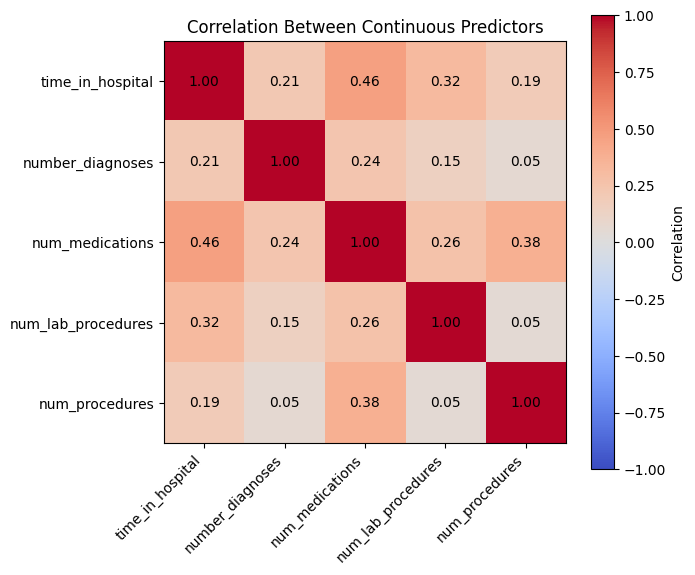

In [6]:
continuous_vars = ['time_in_hospital', 'number_diagnoses', 'num_medications',
                    'num_lab_procedures', 'num_procedures']

corr_matrix = df[continuous_vars].corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(continuous_vars)))
ax.set_yticks(range(len(continuous_vars)))
ax.set_xticklabels(continuous_vars, rotation=45, ha='right')
ax.set_yticklabels(continuous_vars)

# Annotate cells with correlation values
for i in range(len(continuous_vars)):
    for j in range(len(continuous_vars)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.colorbar(im, label='Correlation')
plt.title('Correlation Between Continuous Predictors')
plt.tight_layout()
plt.savefig('../slides/predictor_correlations.png', dpi=150)
plt.show()

## Interpretation: Correlation Between Continuous Predictors

No serious multicollinearity concerns. The highest correlation is
`time_in_hospital` and `num_medications` at 0.46 — a moderate, expected
relationship (longer stays naturally mean more medications administered),
but well below the range (typically 0.7–0.8+) where you'd worry about
unstable coefficient estimates. Every other pair sits below 0.4, and several
(`num_procedures` with `number_diagnoses` and `num_lab_procedures`) are
essentially uncorrelated (0.05).

**Practical takeaway: all five continuous predictors are safe to include
together** in the fixed-effects part of the model without needing to drop
any for redundancy. 